In [1]:
from utils import * 
from graphs import * 
from ent import * 

In [4]:
def graph_height(n, graphs):

    graph_qubit = [i for i in range(n)]

    graph_ent = []

    for Gi in graphs:

        ent = 0
        for i in range(1,n):

            partA = graph_qubit[:i]
            partB = graph_qubit[i:]

            circuit = stim.Circuit()
            circuit.append('I', [n-1])

            Gi.apply_to_circuit(circuit, [i for i in range(n)], random_order=False)

            simulator = stim.TableauSimulator()
            simulator.do_circuit(circuit)
            tableau = simulator.current_inverse_tableau()
            tab_forward = tableau.inverse()

            ent += (1/(n-1))*ent_state(tab_forward, partA, partB)
        
        graph_ent.append(ent)

    return graph_ent


In [5]:
ent_vel_q4 = np.loadtxt('ent_vel-g4.txt')
ent_vel_q5 = np.loadtxt('ent_vel-g5.txt')
ent_vel_q6 = np.loadtxt('ent_vel-g6.txt')


gamma_q4 = graph_height(n=4,graphs=Q4_graph)
gamma_q5 = graph_height(n=5,graphs=Q5_graph)
gamma_q6 = graph_height(n=6,graphs=Q6_graph)


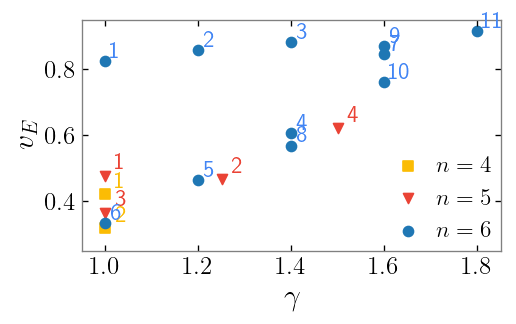

In [6]:
fig, ax = plt.subplots(figsize=(4.5,2.5))


ax.scatter(gamma_q4, ent_vel_q4, marker = 's',color = '#FBBC04',label = '$n=4$')
ax.scatter(gamma_q5, ent_vel_q5, marker = 'v', color = '#EA4335',label = '$n=5$')
ax.scatter(gamma_q6, ent_vel_q6, marker = 'o', color = 'tab:blue',label = '$n=6$')

textfont = {'family':'Calibri'}

for i in range(len(gamma_q4)):
    ax.text(gamma_q4[i] + 0.02, 
            ent_vel_q4[i] + 0.02, 
            s=f'{i + 1}',
            color =  '#FBBC04',
            fontsize=14, 
            fontdict=textfont)




for i in range(len(gamma_q5)):
    ax.text(gamma_q5[i] + 0.02, 
            ent_vel_q5[i] + 0.02, 
            s=f'{i + 1}',
            color =  '#EA4335',
            fontsize=14, 
            fontdict=textfont)

for i in range(len(gamma_q6)):
    ax.text(gamma_q6[i] + 0.01, 
            ent_vel_q6[i] + 0.01, 
            s=f'{i + 1}',
            color =  '#4285F4',
            fontsize=14, 
            fontdict=textfont)


for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.tick_params(top=True, left=True, right=True, bottom=True,
               direction="in", axis='both', which='both', 
               labelsize=15, color='k')

font2 = {'family':'serif', 'color':'black', 'size':18}
plt.xlabel(r"$\gamma$", fontdict=font2)
plt.ylabel(r"$v_E$", fontdict=font2)

# Modified legend placement
plt.legend(
    fontsize=14,  # Slightly smaller font for external legend
    ncol=1,  # Fewer columns for vertical space
    loc='best', 
    # bbox_to_anchor=(1.02, 0.9),  # Positions legend outside axes
    frameon=False,
    borderaxespad=0.,  # Removes padding between axes and legend
    handletextpad=0.2
)
ax.set_ylim(0.25,0.95)
ax.set_xlim(0.95,1.85)
fig.set_dpi(120)

ax.set_yticks([0.4, 0.6, 0.8])
plt.show()